<a href="https://colab.research.google.com/github/pengin-cmd/my-colab-notebooks/blob/main/%E3%82%B3%E3%83%B3%E3%83%9A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install xgboost catboost optuna lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 25.9 MB/s eta 0:00:00


In [9]:
!pip install optuna

In [10]:
pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 12.0 MB/s eta 0:00:00



--- [1-A. LightGBM パラメータ最適化] ---
💡 LGBM 理想の木の数: 495

--- [1-B. XGBoost パラメータ最適化] ---
💡 XGBoost 理想の木の数: 101

--- [1-C. CatBoost パラメータ最適化] ---
💡 CatBoost 理想の木の数: 469

--- [2. 学習フェーズ開始 (LGBM, XGBoost, CatBoost)] ---
>> Running Seed: 42...
>> Running Seed: 2023...
>> Running Seed: 777...
✅ 学習完了: 最終 OOF AUC (加重アンサンブル): 0.8702

--- [3. 予測フェーズ開始] ---
✅ 予測完了: 加重平均アンサンブルによる最終予測を実行しました。

--- [4. エラー分析 (損失原因の特定)] ---
▼ 全体のエラー件数 (is_error = 1): 247 件 / 1568 件

▼ 損失原因度ランキング トップ5:
                    Feature  Error_Importance
0            recent_loyalty         38.757844
1   days_since_registration         18.629954
2  days_since_last_purchase          9.152113
3           education_level          6.408574
4                spend_meat          5.876329

--- [5. 特徴量重要度の算出] ---


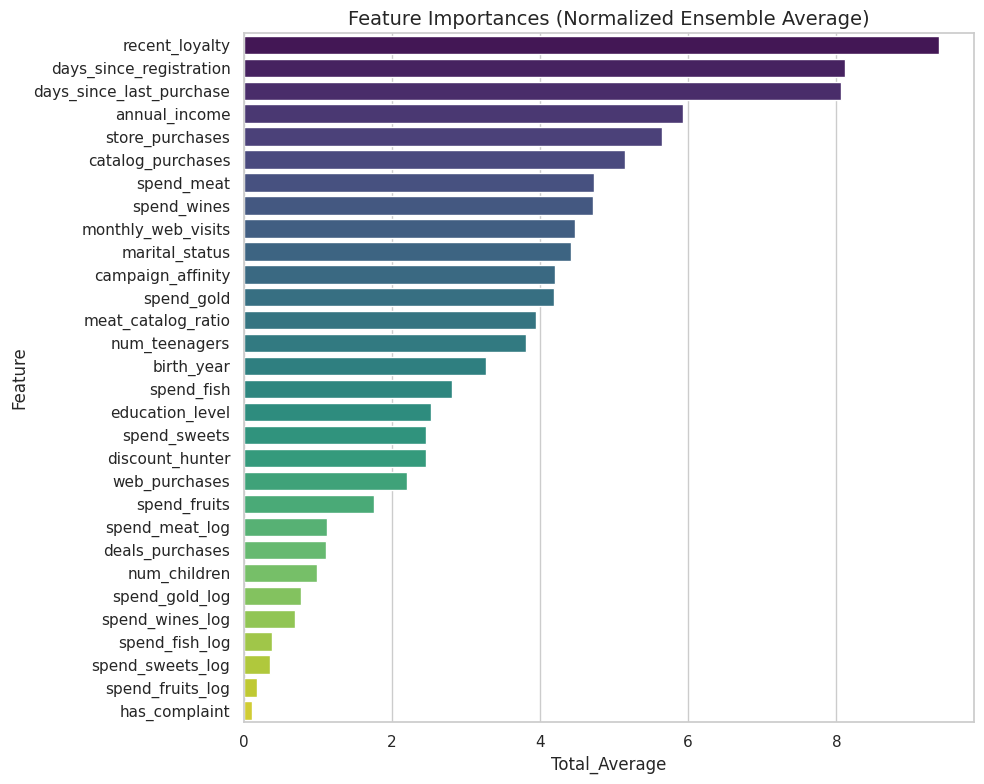


✅ 全工程完了: 'final_submission_trinity.csv' を出力しました！


In [11]:
import pandas as pd
import numpy as np
import warnings
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.tree import DecisionTreeClassifier, export_text
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ==========================================
# 0. 絶対にリークしない事前処理
# ==========================================
def preprocess_safe_row_wise(df):
    df = df.copy()
    base_date = pd.to_datetime('2015-01-01')

    if 'registration_date' in df.columns:
        df['days_since_registration'] = (base_date - pd.to_datetime(df['registration_date'])).dt.days
        df = df.drop('registration_date', axis=1)

    if all(c in df.columns for c in ['spend_wines', 'spend_meat', 'days_since_last_purchase']):
        raw_loyalty = (df['spend_wines'] + df['spend_meat']) / (df['days_since_last_purchase'] + 1)
        df['recent_loyalty'] = np.log1p(raw_loyalty)

    if all(c in df.columns for c in ['spend_meat', 'catalog_purchases']):
        raw_meat_ratio = df['spend_meat'] / (df['catalog_purchases'] + 1)
        df['meat_catalog_ratio'] = np.log1p(raw_meat_ratio)

    if all(c in df.columns for c in ['deals_purchases', 'store_purchases', 'web_purchases', 'catalog_purchases']):
        total_purchases = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
        df['discount_hunter'] = df['deals_purchases'] / (total_purchases + 1)

        if 'recent_loyalty' in df.columns:
            df['campaign_affinity'] = df['recent_loyalty'] * df['discount_hunter']

    spend_cols = [c for c in df.columns if c.startswith('spend_')]
    for col in spend_cols:
        df[col + '_log'] = np.log1p(df[col])

    return df

# ==========================================
# ✨ 1-A. LightGBM チューニング
# ==========================================
def tune_lightgbm_with_optuna(X_raw, y, n_trials=15):
    print("\n--- [1-A. LightGBM パラメータ最適化] ---")
    def objective(trial):
        params = {
            'random_state': 42,
            'n_estimators': 2000,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'class_weight': 'balanced',
            'verbose': -1
        }
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof = np.zeros(len(X_raw))
        fold_best_iters = []

        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)

            cols = ['education_level', 'marital_status']
            enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[cols] = enc.fit_transform(X_tr[cols])
            X_va[cols] = enc.transform(X_va[cols])

            model = LGBMClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[early_stopping(stopping_rounds=30, verbose=False)])
            oof[va_idx] = model.predict_proba(X_va)[:, 1]
            fold_best_iters.append(model.best_iteration_)

        trial.set_user_attr('optimal_iterations', int(np.mean(fold_best_iters)))
        return roc_auc_score(y, oof)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_params.update({
        'random_state': 42,
        'n_estimators': study.best_trial.user_attrs['optimal_iterations'],
        'class_weight': 'balanced',
        'verbose': -1
    })
    print(f"💡 LGBM 理想の木の数: {best_params['n_estimators']}")
    return best_params

# ==========================================
# ✨ 1-B. XGBoost チューニング (新規追加)
# ==========================================
def tune_xgboost_with_optuna(X_raw, y, n_trials=15):
    print("\n--- [1-B. XGBoost パラメータ最適化] ---")
    ratio = float(np.sum(y == 0)) / np.sum(y == 1)

    def objective(trial):
        params = {
            'random_state': 42,
            'n_estimators': 2000,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'scale_pos_weight': ratio,
            'eval_metric': 'logloss',
            'early_stopping_rounds': 30
        }
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof = np.zeros(len(X_raw))
        fold_best_iters = []

        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)

            cols = ['education_level', 'marital_status']
            enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[cols] = enc.fit_transform(X_tr[cols])
            X_va[cols] = enc.transform(X_va[cols])

            model = XGBClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            oof[va_idx] = model.predict_proba(X_va)[:, 1]
            fold_best_iters.append(model.best_iteration)

        trial.set_user_attr('optimal_iterations', int(np.mean(fold_best_iters)))
        return roc_auc_score(y, oof)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_params.update({
        'random_state': 42,
        'n_estimators': study.best_trial.user_attrs['optimal_iterations'],
        'scale_pos_weight': ratio,
        'eval_metric': 'logloss'
    })
    print(f"💡 XGBoost 理想の木の数: {best_params['n_estimators']}")
    return best_params

# ==========================================
# ✨ 1-C. CatBoost チューニング (新規追加)
# ==========================================
def tune_catboost_with_optuna(X_raw, y, n_trials=15):
    print("\n--- [1-C. CatBoost パラメータ最適化] ---")
    categorical_cols = ['education_level', 'marital_status']

    def objective(trial):
        params = {
            'random_state': 42,
            'iterations': 2000,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'depth': trial.suggest_int('depth', 3, 8),
            'auto_class_weights': 'Balanced',
            'cat_features': categorical_cols,
            'verbose': False,
            'early_stopping_rounds': 30
        }
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof = np.zeros(len(X_raw))
        fold_best_iters = []

        for tr_idx, va_idx in skf.split(X_raw, y):
            # CatBoostは文字列をそのまま扱えるため、OrdinalEncoderは不要
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            X_tr[categorical_cols] = X_tr[categorical_cols].astype(str)
            X_va[categorical_cols] = X_va[categorical_cols].astype(str)

            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)

            model = CatBoostClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=False)
            oof[va_idx] = model.predict_proba(X_va)[:, 1]
            fold_best_iters.append(model.get_best_iteration())

        trial.set_user_attr('optimal_iterations', int(np.mean(fold_best_iters)))
        return roc_auc_score(y, oof)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_params.update({
        'random_state': 42,
        'iterations': study.best_trial.user_attrs['optimal_iterations'],
        'auto_class_weights': 'Balanced',
        'cat_features': categorical_cols,
        'verbose': False
    })
    print(f"💡 CatBoost 理想の木の数: {best_params['iterations']}")
    return best_params

# ==========================================
# 2. 学習フェーズ (Train & Validate) - ✨ パラメータ＆重みの適用
# ==========================================
def train_models(X_raw, y, lgb_params, xgb_params, cat_params, seeds=[42, 2023, 777], n_splits=5):
    print(f"\n--- [2. 学習フェーズ開始 (LGBM, XGBoost, CatBoost)] ---")
    artifacts = []
    oof_preds_ensemble = np.zeros(len(X_raw))

    # ✨ 各モデルのアンサンブルの重み（重要度に応じて調整可能）
    # 合計が 1.0 になるように設定します。
    model_weights = {
        'LightGBM': 0.4,
        'XGBoost': 0.3,
        'CatBoost': 0.3
    }

    for seed in seeds:
        print(f">> Running Seed: {seed}...")
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof_seed = np.zeros(len(X_raw))

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y)):
            X_tr, y_tr = X_raw.iloc[train_idx].copy(), y.iloc[train_idx]
            X_va, y_va = X_raw.iloc[val_idx].copy(), y.iloc[val_idx]

            X_tr_cat = X_tr.copy()
            X_va_cat = X_va.copy()
            categorical_cols = ['education_level', 'marital_status']

            X_tr_cat[categorical_cols] = X_tr_cat[categorical_cols].astype(str)
            X_va_cat[categorical_cols] = X_va_cat[categorical_cols].astype(str)

            income_median = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(income_median)
            X_va['annual_income'] = X_va['annual_income'].fillna(income_median)
            X_tr_cat['annual_income'] = X_tr_cat['annual_income'].fillna(income_median)
            X_va_cat['annual_income'] = X_va_cat['annual_income'].fillna(income_median)

            encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[categorical_cols] = encoder.fit_transform(X_tr[categorical_cols])
            X_va[categorical_cols] = encoder.transform(X_va[categorical_cols])

            # ✨ 各モデルに最適化されたパラメータとSeedをセット
            cur_lgb_params = lgb_params.copy(); cur_lgb_params['random_state'] = seed
            cur_xgb_params = xgb_params.copy(); cur_xgb_params['random_state'] = seed
            cur_cat_params = cat_params.copy(); cur_cat_params['random_state'] = seed

            models = {
                'LightGBM': LGBMClassifier(**cur_lgb_params),
                'XGBoost': XGBClassifier(**cur_xgb_params),
                'CatBoost': CatBoostClassifier(**cur_cat_params)
            }

            fold_val_preds = np.zeros(len(X_va))
            for name, model in models.items():
                weight = model_weights[name] # ✨ 重みを取得

                if name == 'LightGBM':
                    model.fit(X_tr, y_tr)
                    fold_val_preds += model.predict_proba(X_va)[:, 1] * weight
                elif name == 'XGBoost':
                    model.fit(X_tr, y_tr, verbose=False)
                    fold_val_preds += model.predict_proba(X_va)[:, 1] * weight
                elif name == 'CatBoost':
                    model.fit(X_tr_cat, y_tr, verbose=False)
                    fold_val_preds += model.predict_proba(X_va_cat)[:, 1] * weight

            oof_seed[val_idx] = fold_val_preds

            # 予測時にも重みを使うため、artifactに保存
            artifacts.append({
                'seed': seed,
                'fold': fold,
                'preprocessors': {'income_median': income_median, 'encoder': encoder, 'cat_cols': categorical_cols},
                'models': models,
                'weights': model_weights,
                'feature_names': list(X_tr.columns)
            })

        oof_preds_ensemble += oof_seed / len(seeds)

    print(f"✅ 学習完了: 最終 OOF AUC (加重アンサンブル): {roc_auc_score(y, oof_preds_ensemble):.4f}")
    return artifacts, oof_preds_ensemble

# ==========================================
# 3. 予測フェーズ (Predict) - ✨ 重み付け適用
# ==========================================
def predict_models(X_test_raw, artifacts):
    print("\n--- [3. 予測フェーズ開始] ---")
    final_test_preds = np.zeros(len(X_test_raw))

    for artifact in artifacts:
        X_te = X_test_raw.copy()
        X_te_cat = X_test_raw.copy()

        preps = artifact['preprocessors']
        models = artifact['models']
        weights = artifact['weights'] # ✨ 学習時に定義した重みを使用

        X_te['annual_income'] = X_te['annual_income'].fillna(preps['income_median'])
        X_te_cat['annual_income'] = X_te_cat['annual_income'].fillna(preps['income_median'])

        X_te_cat[preps['cat_cols']] = X_te_cat[preps['cat_cols']].astype(str)
        X_te[preps['cat_cols']] = preps['encoder'].transform(X_te[preps['cat_cols']])

        # 1つのFold/Seedあたりの加重平均予測値
        fold_test_preds = np.zeros(len(X_test_raw))
        for name, model in models.items():
            if name == 'CatBoost':
                fold_test_preds += model.predict_proba(X_te_cat)[:, 1] * weights[name]
            else:
                fold_test_preds += model.predict_proba(X_te)[:, 1] * weights[name]

        final_test_preds += fold_test_preds

    # 全モデルの合計ではなく、回した数(Fold数 × Seed数)で割って平均をとる
    final_test_preds /= len(artifacts)
    print(f"✅ 予測完了: 加重平均アンサンブルによる最終予測を実行しました。")
    return final_test_preds

# ==========================================
# 4. & 5. 可視化関数 (そのまま)
# ==========================================
def analyze_error_patterns(X_raw, y, oof_preds):
    print("\n--- [4. エラー分析 (損失原因の特定)] ---")
    error_df = X_raw.copy()
    error_df['target'] = y
    error_df['pred_class'] = (oof_preds >= 0.5).astype(int)
    error_df['is_error'] = (error_df['target'] != error_df['pred_class']).astype(int)
    print(f"▼ 全体のエラー件数 (is_error = 1): {error_df['is_error'].sum()} 件 / {len(error_df)} 件")

    X_error = X_raw.copy()
    X_error['annual_income'] = X_error['annual_income'].fillna(X_error['annual_income'].median())
    cols = ['education_level', 'marital_status']
    X_error[cols] = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(X_error[cols])

    error_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
    error_model.fit(X_error, error_df['is_error'])

    error_importance = pd.DataFrame({'Feature': X_error.columns, 'Error_Importance': error_model.feature_importances_ * 100}).sort_values(by='Error_Importance', ascending=False).reset_index(drop=True)
    print("\n▼ 損失原因度ランキング トップ5:")
    print(error_importance.head(5))
    return error_importance

def plot_feature_importances(artifacts):
    print("\n--- [5. 特徴量重要度の算出] ---")
    f_names = artifacts[0]['feature_names']
    importance_df = pd.DataFrame({'Feature': f_names})
    total_imps = np.zeros(len(f_names))
    total_models = 0
    scaler = MinMaxScaler()

    for art in artifacts:
        for name, model in art['models'].items():
            raw_imp = model.feature_importances_
            scaled_imp = scaler.fit_transform(raw_imp.reshape(-1, 1)).flatten()
            total_imps += scaled_imp
            total_models += 1

    importance_df['Total_Average'] = (total_imps / total_models)
    importance_df['Total_Average'] = (importance_df['Total_Average'] / importance_df['Total_Average'].sum()) * 100
    importance_df = importance_df.sort_values(by='Total_Average', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Total_Average', y='Feature', data=importance_df, palette='viridis')
    plt.title('Feature Importances (Normalized Ensemble Average)', fontsize=14)
    plt.tight_layout()
    plt.show()

# ==========================================
# メイン実行ブロック
# ==========================================
if __name__ == "__main__":
    train_data = pd.read_csv('train.csv')
    test_data = pd.read_csv('test.csv')

    train_df = preprocess_safe_row_wise(train_data)
    test_df = preprocess_safe_row_wise(test_data)

    X_raw = train_df.drop(['customer_id', 'target'], axis=1)
    y = train_df['target']
    X_test_raw = test_df.drop(['customer_id'], axis=1, errors='ignore')

    # ✨ 1. 各モデルを個別にチューニング実行（テスト時はn_trials=5など減らすと早く終わります）
    best_lgb_params = tune_lightgbm_with_optuna(X_raw, y, n_trials=10)
    best_xgb_params = tune_xgboost_with_optuna(X_raw, y, n_trials=10)
    best_cat_params = tune_catboost_with_optuna(X_raw, y, n_trials=10)

    # ✨ 2. それぞれの最適パラメータを全て渡して学習
    artifacts, oof_predictions = train_models(X_raw, y, best_lgb_params, best_xgb_params, best_cat_params)

    # 3. 予測
    final_predictions = predict_models(X_test_raw, artifacts)

    analyze_error_patterns(X_raw, y, oof_predictions)
    plot_feature_importances(artifacts)

    submission = pd.DataFrame({'customer_id': test_data['customer_id'], 'target': final_predictions})
    submission.to_csv('final_submission_trinity.csv', index=False)
    print("\n✅ 全工程完了: 'final_submission_trinity.csv' を出力しました！")

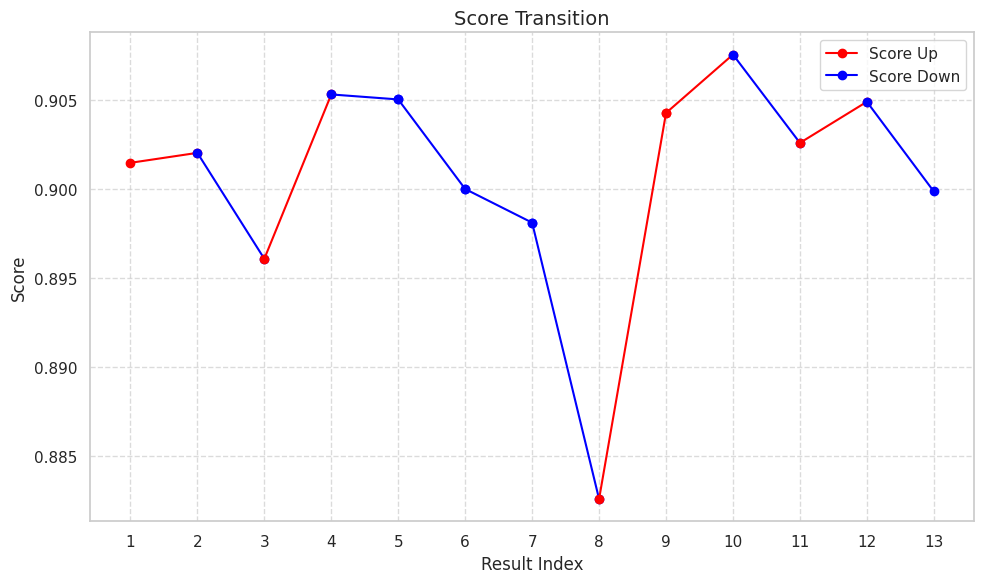

In [12]:
import os
import re
import glob
import matplotlib.pyplot as plt
import matplotlib.lines as mlines # 凡例のカスタマイズ用に追加

# 1. カレントディレクトリ内の "result_*.csv" ファイルを取得
file_names = glob.glob("result_*.csv")

data = []
# ファイル名からインデックスとスコアを抽出する正規表現
# 例: result_1(0.90147 点).csv -> インデックス: 1, スコア: 0.90147
pattern = r"result_(\d+)\(([\d.]+)\s*点\)\.csv"

for fn in file_names:
    # パスが含まれている場合はファイル名のみを抽出
    basename = os.path.basename(fn)
    match = re.search(pattern, basename)
    if match:
        idx = int(match.group(1))
        score = float(match.group(2))
        data.append((idx, score))

# 2. インデックス(1, 2, 3...)の順にソート
data.sort(key=lambda x: x[0])

# X軸（インデックス）とY軸（スコア）のリストに分離
indices = [x[0] for x in data]
scores = [x[1] for x in data]

# 3. グラフの描画
plt.figure(figsize=(10, 6))

# データが複数ある場合のみ線を描画
if len(indices) > 1:
    for i in range(len(indices) - 1):
        x_seg = [indices[i], indices[i+1]]
        y_seg = [scores[i], scores[i+1]]

        # 前のスコアより上がっていれば赤、下がっていれば（または同じなら）青
        if scores[i+1] > scores[i]:
            line_color = 'red'
        else:
            line_color = 'blue'

        plt.plot(x_seg, y_seg, marker='o', linestyle='-', color=line_color)
elif len(indices) == 1:
    # データが1つしかない場合は点のみ描画
    plt.plot(indices, scores, marker='o', color='black')

# グラフの装飾
plt.title('Score Transition', fontsize=14)
plt.xlabel('Result Index', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(indices) # X軸の目盛りを1, 2, 3...と整数に合わせる
plt.grid(True, linestyle='--', alpha=0.7)

# カスタム凡例の作成（ループで描画すると凡例が複数出てしまうのを防ぐため）
if len(indices) > 1:
    red_line = mlines.Line2D([], [], color='red', marker='o', label='Score Up')
    blue_line = mlines.Line2D([], [], color='blue', marker='o', label='Score Down')
    plt.legend(handles=[red_line, blue_line])

plt.tight_layout()

# 画像として保存する場合
plt.savefig('score_transition.png')

# 画面に表示する場合 (Jupyter Notebook等の場合はこちらのコメントアウトを外してください)
# plt.show()